## Toy Problem 1 (coin)

 Progress                  Draws   Divergences   Step size   Grad evals   Sampling Speed     Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━   3000    0             1.54        1            11191.29 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━   3000    0             1.07        1            10274.36 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━   3000    0             1.04        3            8797.21 draws/s    0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━   3000    0             1.18        3            7611.26 draws/s    0:00:00   0:00:00

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
p  0.788  0.056   0.687    0.892      0.001    0.001    3036.0    4796.0   

   r_hat  
p    1.0  


array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

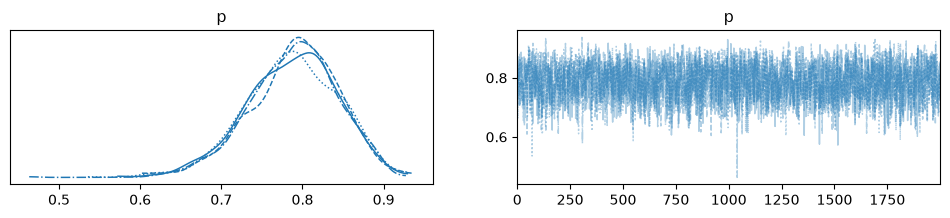

In [1]:
import pymc as pm
import numpy as np
import arviz as az

true_p = 0.7
data = np.random.binomial(1, true_p, size=50)

with pm.Model() as m:
    p = pm.Uniform("p", 0, 1)
    y = pm.Bernoulli("y", p=p, observed=data)
    idata = pm.sample(2000, tune=1000, chains=4)

print(az.summary(idata))
az.plot_trace(idata)

## Toy Problem 2 ( logistic)

 Progress                   Draws   Divergences   Step size   Grad evals   Sampling Speed    Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.88        3            3288.66 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.95        3            3085.84 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.77        3            2929.20 draws/s   0:00:01   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.90        1            2660.91 draws/s   0:00:01   0:00:00

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
slope      1.204  0.280   0.692    1.716      0.004    0.003    4745.0   
intercept -0.839  0.449  -1.689   -0.004      0.006    0.005    5520.0   

           ess_tail  r_hat  
slope        4883.0    1.0  
intercept    4895.0    1.0  


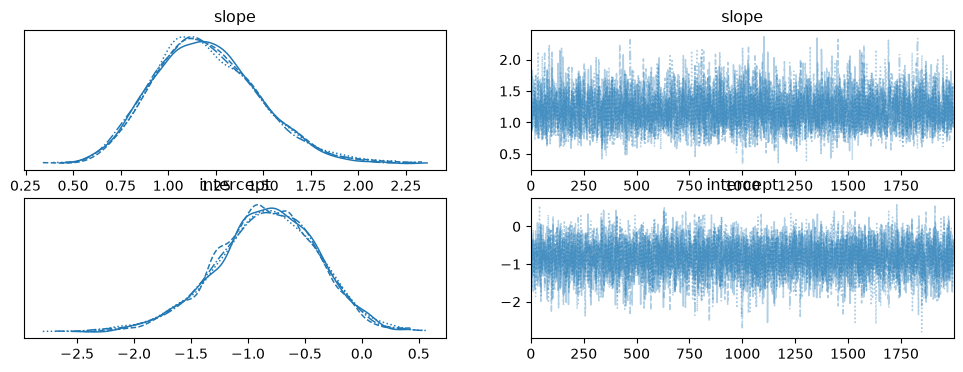

In [4]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# 1. Synthetic data with KNOWN parameters
true_slope, true_intercept = 1.5, -2.0
x = np.linspace(-4, 4, 60)
prob = 1 / (1 + np.exp(-(true_slope*x + true_intercept)))   # true S-curve
y = np.random.binomial(1, prob)                             # yes/no outcomes

# 2. Bayesian model
with pm.Model() as logistic:
    slope     = pm.Normal("slope", 0, 5)
    intercept = pm.Normal("intercept", 0, 5)
    logit = slope*x + intercept
    obs = pm.Bernoulli("obs", logit_p=logit, observed=y)
    idata = pm.sample(2000, tune=1000, chains=4)

# 3. Check results
print(az.summary(idata))

# 4. Trace plot
az.plot_trace(idata)
plt.show()



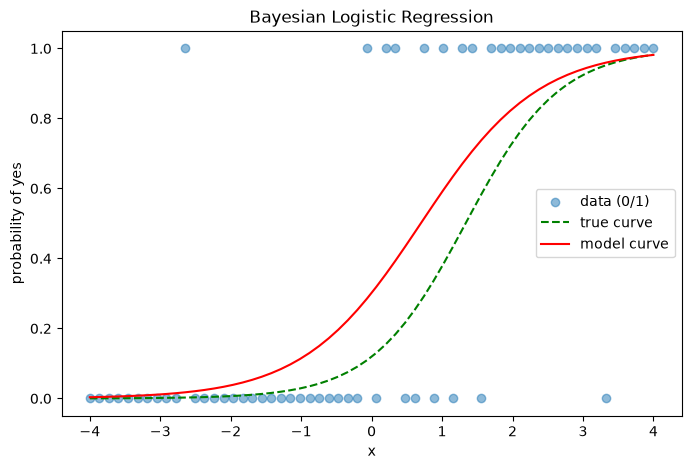

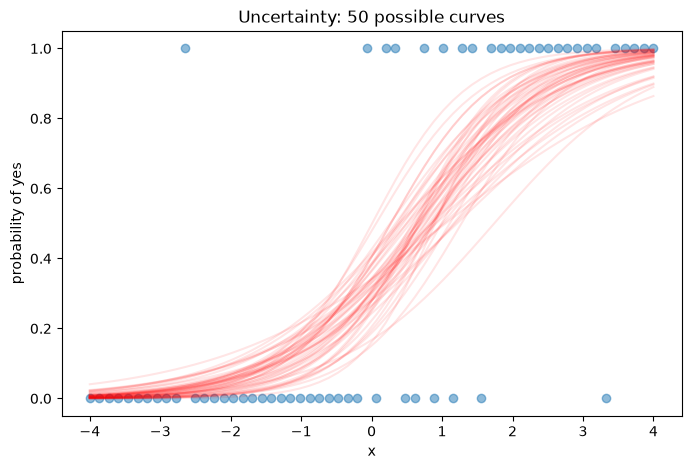

In [5]:
# 5. Fit plot: data + true curve + model curve
slope_est = idata.posterior["slope"].mean().item()
int_est   = idata.posterior["intercept"].mean().item()
prob_est  = 1 / (1 + np.exp(-(slope_est*x + int_est)))

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.5, label="data (0/1)")
plt.plot(x, prob, "g--", label="true curve")
plt.plot(x, prob_est, "r-", label="model curve")
plt.xlabel("x"); plt.ylabel("probability of yes")
plt.legend(); plt.title("Bayesian Logistic Regression")
plt.show()

# 6. Uncertainty plot: 50 possible curves
slopes = idata.posterior["slope"].values.flatten()
ints   = idata.posterior["intercept"].values.flatten()

plt.figure(figsize=(8,5))
for i in np.random.choice(len(slopes), 50):
    p = 1 / (1 + np.exp(-(slopes[i]*x + ints[i])))
    plt.plot(x, p, color="red", alpha=0.1)
plt.scatter(x, y, alpha=0.5)
plt.xlabel("x"); plt.ylabel("probability of yes")
plt.title("Uncertainty: 50 possible curves")
plt.show()

## Toy Problem 3 (linear)

 Progress                   Draws   Divergences   Step size   Grad evals   Sampling Speed    Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.47        7            2566.20 draws/s   0:00:01   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.57        7            2355.16 draws/s   0:00:01   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.40        7            2466.81 draws/s   0:00:01   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.56        7            2365.55 draws/s   0:00:01   0:00:00

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
slope      1.953  0.030   1.897    2.009      0.001    0.000    3174.0   
intercept -0.682  0.171  -1.019   -0.387      0.003    0.003    3200.0   
sigma      0.550  0.067   0.430    0.669      0.001    0.001    4165.0   

           ess_tail  r_hat  
slope        3396.0    1.0  
intercept    3430.0    1.0  
sigma        3752.0    1.0  


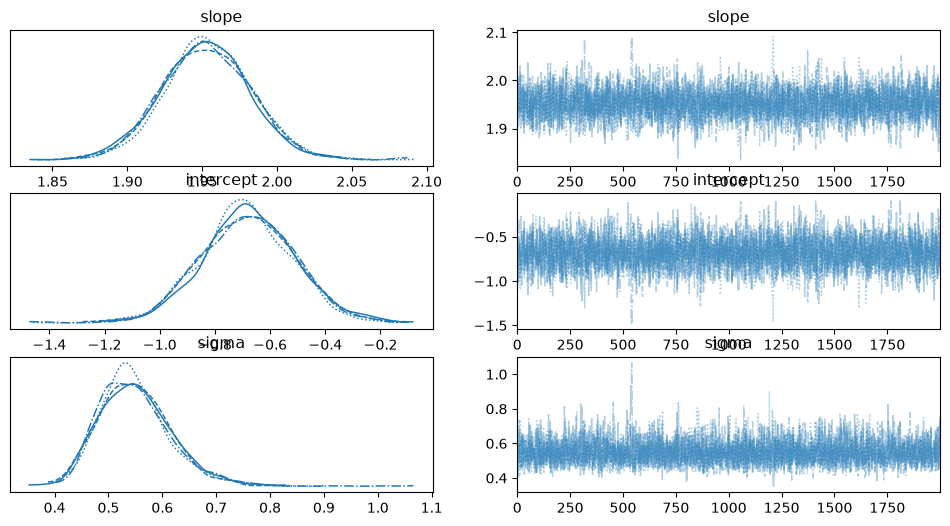

In [6]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# 1. Synthetic data with KNOWN parameters
true_slope, true_intercept, true_sigma = 2.0, -1.0, 0.5
x = np.linspace(0, 10, 40)
y = true_slope*x + true_intercept + np.random.normal(0, true_sigma, size=x.size)

# 2. Bayesian model
with pm.Model() as lin:
    slope     = pm.Normal("slope", 0, 10)
    intercept = pm.Normal("intercept", 0, 10)
    sigma     = pm.HalfNormal("sigma", 5)
    mu = slope*x + intercept
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y)
    idata = pm.sample(2000, tune=1000, chains=4)

# 3. Check results
print(az.summary(idata))

# 4. Trace plot
az.plot_trace(idata)
plt.show()


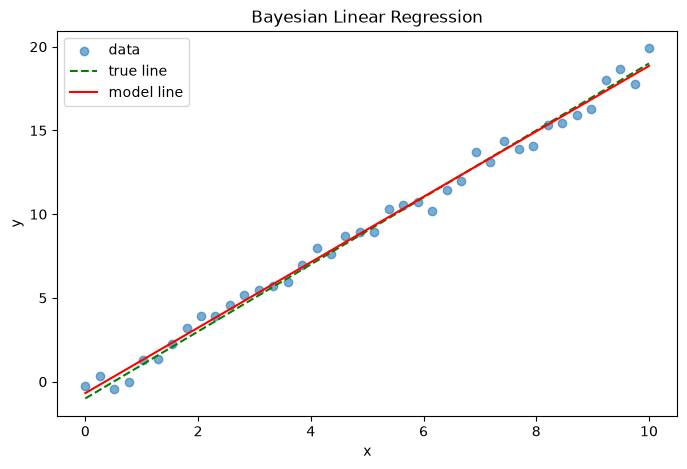

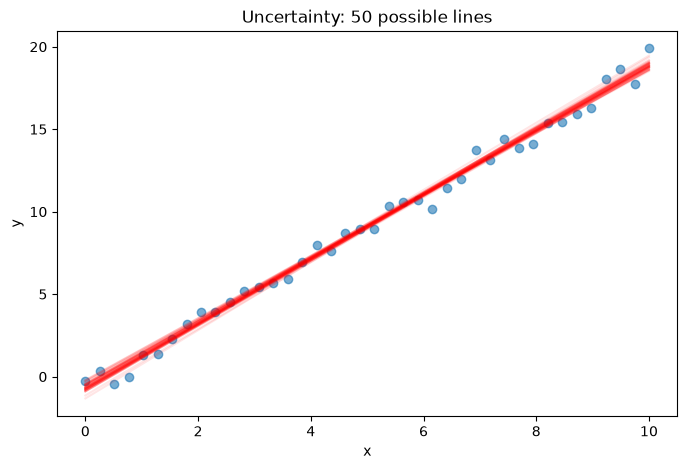

In [8]:
# 5. Fit plot: data + true line + model line
slope_est = idata.posterior["slope"].mean().item()
int_est   = idata.posterior["intercept"].mean().item()
y_est     = slope_est*x + int_est

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.6, label="data")
plt.plot(x, true_slope*x + true_intercept, "g--", label="true line")
plt.plot(x, y_est, "r-", label="model line")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(); plt.title("Bayesian Linear Regression")
plt.show()

# 6. Uncertainty plot: 50 possible lines
slopes = idata.posterior["slope"].values.flatten()
ints   = idata.posterior["intercept"].values.flatten()

plt.figure(figsize=(8,5))
for i in np.random.choice(len(slopes), 50):
    plt.plot(x, slopes[i]*x + ints[i], color="red", alpha=0.1)
plt.scatter(x, y, alpha=0.6)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Uncertainty: 50 possible lines")
plt.show()